<a href="https://colab.research.google.com/github/WahyuKhairi06/JaringanSyarafTiruan_WahyuKhairi_2311531009/blob/main/Tugas%20Akhir%20JST/Project_JST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
# ================================
# Step 1: Persiapan Lingkungan
# ================================
!pip install torch torchvision matplotlib scikit-learn pillow

import os
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from PIL import Image
from google.colab import drive

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [24]:
# ================================
# Step 2: Mount Google Drive & Persiapan Dataset
# ================================
drive.mount('/content/drive')

# Path ZIP file di Google Drive
zip_path = "/content/drive/MyDrive/Informatika/SMT 5/jaringan Syaraf tiruan/trash_image.zip"
extract_path = "/content/trash_1/"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)

# Cek struktur folder
classes = os.listdir(extract_path)
print("Classes found:", classes)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset extracted to: /content/trash_1/
Classes found: ['metal', 'glass', 'trash', 'plastic', 'paper', 'cardboard']


metal: 410 images
glass: 501 images
trash: 137 images
plastic: 482 images
paper: 594 images
cardboard: 403 images


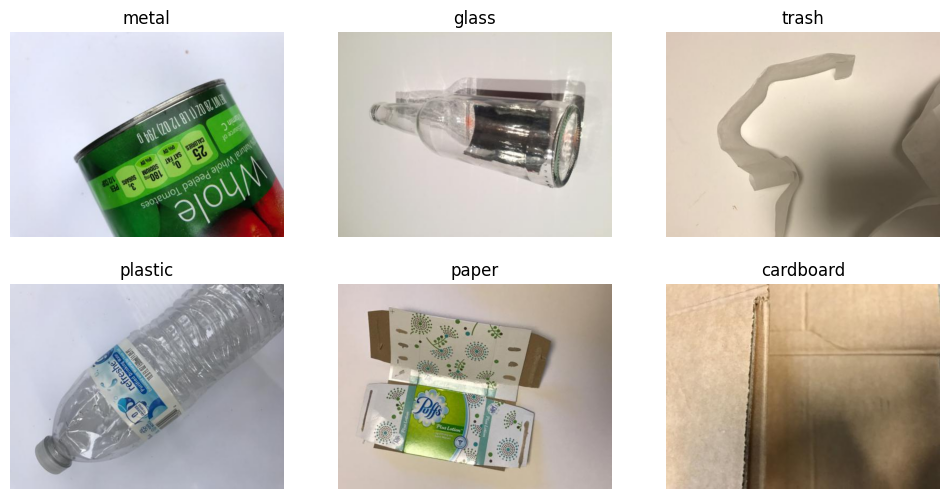

In [25]:
# ================================
# Step 3: Eksplorasi Dataset
# ================================
for cls in classes:
    cls_path = os.path.join(extract_path, cls)
    print(f"{cls}: {len(os.listdir(cls_path))} images")

plt.figure(figsize=(12,6))
for i, cls in enumerate(classes):
    cls_folder = os.path.join(extract_path, cls)
    img_path = os.path.join(cls_folder, os.listdir(cls_folder)[0])
    img = Image.open(img_path)
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
plt.show()

In [26]:
# ================================
# Step 4: Preprocessing & Augmentasi
# ================================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

In [27]:
# ================================
# Step 5: Split Dataset
# ================================
full_dataset = datasets.ImageFolder(extract_path, transform=transform)
num_classes = len(full_dataset.classes)
print("Total images:", len(full_dataset))
print("Class to index mapping:", full_dataset.class_to_idx)

train_size = int(0.7 * len(full_dataset))
val_size   = int(0.15 * len(full_dataset))
test_size  = len(full_dataset) - train_size - val_size

train_set, val_set, test_set = random_split(full_dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_set, batch_size=32, shuffle=False)

Total images: 2527
Class to index mapping: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [28]:
# ================================
# Step 6: Definisi Model
# ================================
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
model = model.to(device)

In [29]:
# ================================
# Step 7: Setup Training
# ================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 10

In [30]:
# ================================
# Step 8: Training Model
# ================================
best_val_acc = 0.0
train_losses, val_losses = [], []
train_acc_list, val_acc_list = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, running_corrects = 0.0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs,1)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc  = running_corrects.double() / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    train_acc_list.append(epoch_acc.item())

    # Validation
    model.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs,1)
            val_corrects += torch.sum(preds == labels.data)

    val_epoch_loss = val_loss / len(val_loader.dataset)
    val_epoch_acc  = val_corrects.double() / len(val_loader.dataset)
    val_losses.append(val_epoch_loss)
    val_acc_list.append(val_epoch_acc.item())

    print(f"Epoch {epoch+1}/{num_epochs}: Train Loss={epoch_loss:.4f}, Acc={epoch_acc:.4f}, Val Loss={val_epoch_loss:.4f}, Val Acc={val_epoch_acc:.4f}")

    # Simpan model terbaik
    if val_epoch_acc > best_val_acc:
        best_val_acc = val_epoch_acc
        torch.save(model.state_dict(), "best_model.pth")

Epoch 1/10: Train Loss=0.7174, Acc=0.7545, Val Loss=0.4408, Val Acc=0.8628
Epoch 2/10: Train Loss=0.3229, Acc=0.8914, Val Loss=0.4390, Val Acc=0.8681
Epoch 3/10: Train Loss=0.1915, Acc=0.9383, Val Loss=0.5854, Val Acc=0.8602
Epoch 4/10: Train Loss=0.2673, Acc=0.9129, Val Loss=0.4297, Val Acc=0.8971
Epoch 5/10: Train Loss=0.2217, Acc=0.9259, Val Loss=0.3745, Val Acc=0.8865
Epoch 6/10: Train Loss=0.1292, Acc=0.9564, Val Loss=0.3323, Val Acc=0.8997
Epoch 7/10: Train Loss=0.1163, Acc=0.9627, Val Loss=0.3789, Val Acc=0.8997
Epoch 8/10: Train Loss=0.1032, Acc=0.9683, Val Loss=0.3996, Val Acc=0.9024
Epoch 9/10: Train Loss=0.1035, Acc=0.9672, Val Loss=0.4888, Val Acc=0.8892
Epoch 10/10: Train Loss=0.0890, Acc=0.9695, Val Loss=0.4277, Val Acc=0.8813


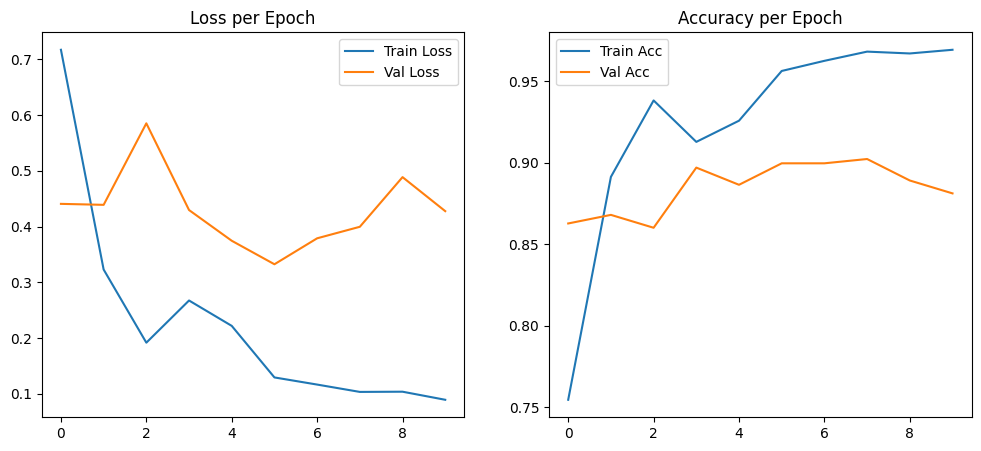

In [31]:
# ================================
# Step 9: Evaluasi Model
# ================================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss per Epoch")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_acc_list, label="Train Acc")
plt.plot(val_acc_list, label="Val Acc")
plt.title("Accuracy per Epoch")
plt.legend()
plt.show()



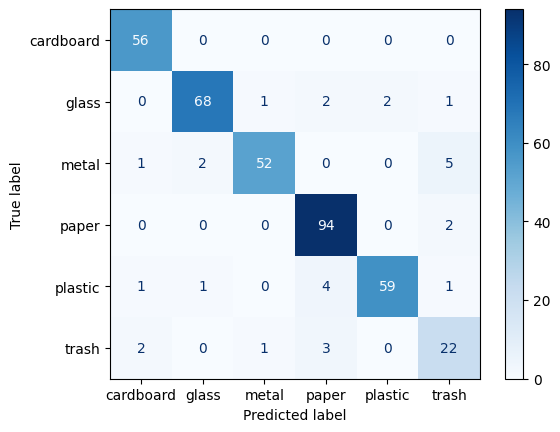

In [32]:
# Load best model
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs,1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=full_dataset.classes)
disp.plot(cmap=plt.cm.Blues)
plt.show()


In [33]:
# ================================
# Step 10: Testing Gambar Baru
# ================================
def predict_image(image_path, model, class_names):
    img = Image.open(image_path).convert("RGB")
    transform_test = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])
    img = transform_test(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        outputs = model(img)
        _, pred = torch.max(outputs,1)
    print(f"Predicted class: {class_names[pred.item()]}")

# Contoh penggunaan:
predict_image("/content/test.jpg", model, full_dataset.classes)

Predicted class: trash


In [34]:
# ================================
# Step 11: Testing Gambar Baru
# ================================
def predict_image(image_path, model, class_names):
    img = Image.open(image_path).convert("RGB")
    transform_test = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])
    img = transform_test(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        outputs = model(img)
        _, pred = torch.max(outputs,1)
    print(f"Predicted class: {class_names[pred.item()]}")

# Contoh penggunaan:
predict_image("/content/metal.jpeg", model, full_dataset.classes)

Predicted class: cardboard


In [35]:
# ================================
# Step 12: Testing Gambar Baru
# ================================
def predict_image(image_path, model, class_names):
    img = Image.open(image_path).convert("RGB")
    transform_test = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])
    img = transform_test(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        outputs = model(img)
        _, pred = torch.max(outputs,1)
    print(f"Predicted class: {class_names[pred.item()]}")

# Contoh penggunaan:
predict_image("/content/botol_plastik.jpg", model, full_dataset.classes)

Predicted class: glass


In [36]:
# =====================================
# Fungsi Training untuk Eksperimen Optimizer
# =====================================
def train_with_optimizer(optimizer_name, model, optimizer, criterion, train_loader, val_loader, num_epochs=5):
    print(f"\n============================")
    print(f"Training menggunakan {optimizer_name}")
    print(f"============================")

    best_val_acc = 0.0

    for epoch in range(num_epochs):
        model.train()
        running_loss, running_corrects = 0.0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)

        train_acc = running_corrects.double() / len(train_loader.dataset)

        # Validation
        model.eval()
        val_corrects = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs,1)
                val_corrects += torch.sum(preds == labels.data)

        val_acc = val_corrects.double() / len(val_loader.dataset)

        print(f"Epoch {epoch+1}/{num_epochs}  Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc

    return float(best_val_acc)


In [37]:
# =====================================
# Step 11: Eksperimen 3 Optimizer
# =====================================
import copy
results = {}

optimizers = {
    "Adam": optim.Adam(model.parameters(), lr=0.001),
    "SGD": optim.SGD(model.parameters(), lr=0.001, momentum=0.9),
    "RMSprop": optim.RMSprop(model.parameters(), lr=0.001)
}

for name, opt in optimizers.items():
    # Reset model setiap eksperimen
    temp_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    temp_model.classifier[1] = nn.Linear(temp_model.classifier[1].in_features, num_classes)
    temp_model = temp_model.to(device)

    # Train dan ambil best validation accuracy
    best_acc = train_with_optimizer(name, temp_model, opt, criterion, train_loader, val_loader, num_epochs=5)
    results[name] = best_acc



Training menggunakan Adam
Epoch 1/5  Train Acc: 0.1804 | Val Acc: 0.2005
Epoch 2/5  Train Acc: 0.1782 | Val Acc: 0.2005
Epoch 3/5  Train Acc: 0.1816 | Val Acc: 0.1926
Epoch 4/5  Train Acc: 0.1742 | Val Acc: 0.1847
Epoch 5/5  Train Acc: 0.1810 | Val Acc: 0.1794

Training menggunakan SGD
Epoch 1/5  Train Acc: 0.1923 | Val Acc: 0.2190
Epoch 2/5  Train Acc: 0.1827 | Val Acc: 0.2401
Epoch 3/5  Train Acc: 0.1980 | Val Acc: 0.2401
Epoch 4/5  Train Acc: 0.1883 | Val Acc: 0.2269
Epoch 5/5  Train Acc: 0.1923 | Val Acc: 0.2111

Training menggunakan RMSprop
Epoch 1/5  Train Acc: 0.1493 | Val Acc: 0.1372
Epoch 2/5  Train Acc: 0.1363 | Val Acc: 0.1504
Epoch 3/5  Train Acc: 0.1533 | Val Acc: 0.1214
Epoch 4/5  Train Acc: 0.1403 | Val Acc: 0.1346
Epoch 5/5  Train Acc: 0.1561 | Val Acc: 0.1372


In [38]:
# =====================================
# Step 12: Tabel Hasil Perbandingan
# =====================================

import pandas as pd

df_results = pd.DataFrame({
    "Optimizer": list(results.keys()),
    "Best Validation Accuracy": list(results.values())
})

print("\n\n===== PERBANDINGAN OPTIMIZER =====\n")
print(df_results)




===== PERBANDINGAN OPTIMIZER =====

  Optimizer  Best Validation Accuracy
0      Adam                  0.200528
1       SGD                  0.240106
2   RMSprop                  0.150396
